Introduction to PyTorch

In [ ]:
from torch import nn
import torch

In [ ]:
# Random tensors
# Random tensors are important because the way many neural networks learn is that they start with tensors full of random numbers then adjust those random numbers to better represent the data
# Start with random numbers -> look at data -> update random numbers -> look at data -> update random numbers
# Create a random tensor or shape (3, 4)

random_tensor = torch.rand(3, 4)
random_tensor.ndim # 2 dimension tensor 

In [ ]:
# Create a random tensor with similar shape to an image tensor 

random_image_size_tensor = torch.rand(size=(224, 224, 3)) # height, width, colour channels (R, G, B)
random_image_size_tensor.shape, random_image_size_tensor.ndim

In [ ]:
tensor = torch.arange(0,9)

In [ ]:
# Tensor datatypes 
# 3 important parameters while creating tensors
# Tensor datatype is one of the 3 big issues with PyTorch and deep learning. For example can be errors with doing calculations with float 16 and float 32 tensors 

float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None, # what datatype is the tensor (e.g. float 32 or float 16). To do with precision in computer science. 16 bit saves some compute time.
                               device=None, # 'cuda' if using a GPU. Can't have some tensors on a GPU and some on a CPU and do calculations 
                               requires_grad=False) # for gradient descent, whether or not to track gradients with this operation

float_32_tensor.dtype

In [ ]:
float_16_tensor = float_32_tensor.type(torch.float16)
float_16_tensor.dtype

In [ ]:
t1 = torch.tensor([1,2,3],
                  dtype=torch.float32)
t1.mean()


In [ ]:
# Reshaping - reshapes an input tensor to a defined shape
# View - return a view of an input tensor of a certain shape but keep the same memory as the origial tensor
# Stacking - combine multiple tensors on top of each other (vstack) or side by side (hstack)
# Squeeze - removes all1 dimensions from a tensor
# Unsqueeze - add a 1 dimension to a target tensor 
# Permute - return a view of the input with dimensions permuted (swapped) in a certain way

import torch
x = torch.arange(1., 11.)
x, x.shape

# Add an extra dimension
x_reshaped = x.reshape(1, 10) # adds an extra bracket
x_reshaped, x_reshaped.shape

# Change the view. Changes z changes x (because a view of a tensor shares the same memory as the original tensor)
z = x.view(1, 10)
z, z.shape

# Stack tensors on top of each other
x_stacked = torch.stack([x, x, x, x], dim=0)
x_stacked, x_stacked.shape

# Squeeze removes all single dimensions
x_squeeze = x.squeeze()
x_squeeze

# Unsqueeze adds a single dimension
x_unsqueeze = x_squeeze.unsqueeze(dim=1)
x_unsqueeze

# Permute rearranges the dimensions of a target tensor in a specified order
x_original = torch.rand(size=(224, 224, 3)) # [height, width, colour_channesl]
x_permuted = x_original.permute(2, 0, 1) # shifts axis 0 -> 1, 1 -> 2, 2 -> 0
x_permuted, x_permuted.shape

 

In [ ]:
# PyTorch tensors and NumPy

# Data in NumPy , want in PyTorch tensor - torch.from_numpy_ndarray
# Data in PyTorch, want in NumPy - torch.Tensor.numpy()


import torch
import numpy as np

array = np.arange(1.0, 8.0)
tensor = torch.from_numpy(array) # warning : when converting from numpy, pytorch reflects numpy's refault data type of float64
array, tensor

In [ ]:
# Change the value of array, what will this do to tensor?

array += 1
array, tensor

In [ ]:
# Tensor to NumPy array

tensor = torch.ones(7)
numpy_tensor = tensor.numpy()
tensor, numpy_tensor

In [ ]:
# Reproducbility - trying to take random out of random

random_seed = 42
torch.manual_seed(random_seed)
random_tensor_C = torch.rand(3, 4)
random_tensor_C


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
tensor = torch.tensor([1, 2, 3])
print(tensor, tensor.device)

# Move to GPU if available
tensor_on_gpu = tensor.to(device)
print(tensor_on_gpu)

# Moving tensors back to the CPU
# If tensor is on GPU, can't transform it to NumPy
tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()
print(tensor_back_on_cpu)



PyTorch Workflow

In [1]:
# PyTorch Workflow
# Explore an example PyTorch end-to-end workflow

import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks 
import matplotlib.pyplot as plt


In [2]:
# Linear regression
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias


In [3]:
# Splitting data into training and testing sets
# Create a train/set split

train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):
    # Plots training data, test data and compares predictions 

    plt.figure(figsize=(10,7))

    # Plot training data in pink
    plt.scatter(train_data, train_labels, color='Pink', s=4, label='Training data')

    # Plot test data in green
    plt.scatter(test_data, test_labels, color='Blue', s=4, label='Testing data')

    # Are there predictions?
    if predictions is not None:
        plt.scatter(test_data, predictions, color='Red', s=4, label='Training data')

    plt.xlabel('X vals')
    plt.ylabel('y vals')
    plt.legend()
    plt.show()

# plot_predictions()

In [4]:
# Build model
# Building our first PyTorch model - Linear Regression

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,    # starting with a random weight and try to adjust it to the ideal weight
                                                  requires_grad=True, 
                                                  dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, 
                                               requires_grad=True,
                                               dtype=torch.float))
          

        # Forward method to define the computation in the model
        # Forward method required when using nn.Module
    def forward(self, x: torch.Tensor) -> torch.Tensor: # x is the input data
        return self.weights * x + self.bias # linear regression formula

In [300]:
# PyTorch model building essentials 

# torch.nn - contains all of the buildings for computational graphs (a nn can be considered a computation graph)
# torch.nn.Parameter - what parameters should our model try and learn
# torch.nn.Module - the base class for all neural network modules, if you subclass it, you should overwrite forward()
# torch.optim - this is where the optimisers in PyTorch are, they will help with gradient descent 

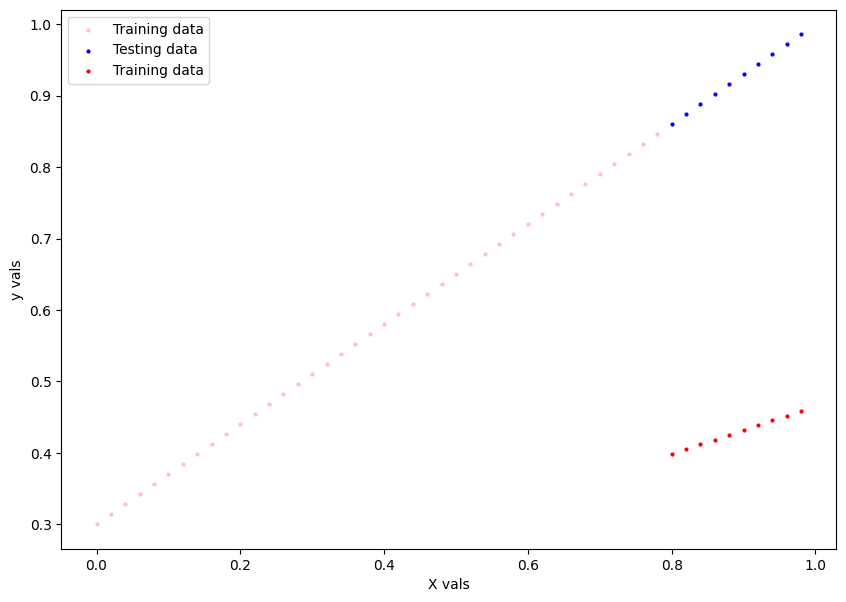

In [16]:
# Checking the contents of our PyTorch module
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model
model_0 = LinearRegressionModel()

# Parameters
list(model_0.parameters())

# List named parameters
model_0.state_dict()

# Making predictions using torch.inference_mode()
# To check our models predictive power, let's see how well it predicts y_test based on X_test
# When we pass data through our model, it's going to run it through our model info

with torch.inference_mode():
    y_preds = model_0(X_test)

plot_predictions(predictions=y_preds)

# Not good model yet as initialised with random data 

In [302]:
# Train model

# The idea of training is for a model to move from some unknown parameters (possibly random) to some known parameters
# To a better representation of the data 
# Can measure the representation by the loss function

# What we need
# Loss function : a function to measure how wrong your model's predictions are to the ideal outputs
# Optimiser : takes into account the loss of a model and adjusts the model's parameters to improve the loss function
# A training loop
# A testing loop

In [18]:
# Set up a loss function
loss_fn = nn.L1Loss()

# Set up an optimiser - stochastic gradient descent 
optimiser = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

# Building a training loop 
# Things we need in a training loop:
# 1. Loop through the data
# 2. Forward pass - involves data moving through our model's forward function to make predictions 
# 3. Calculate the loss - compare forward pass predictions to ground truth labels
# 4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (backpropagation)
# 5. Optimiser step - use the optimiser to adjust our model's parameters to try and improve the loss

In [ ]:
torch.manual_seed(42)

# An epoch is one loop through the data
epochs = 100 # Hyperparameter as we have set it ourselves

# Track different values 
epoch_count = []
loss_values = []
test_loss_values = []

# Training 
for epoch in range(epochs):
    # Set the model to training mode
    model_0.train() # train mode sets all parameters that require gradients to require gradients 

    # 1. Forward pass 
    y_pred = model_0(X_train)

    # 2. Calculate the loss 
    loss = loss_fn(y_pred, y_train)

    # 3. Opitimiser zero grad
    optimiser.zero_grad()

    # 4. Perform backpropagation on the loss with respect to the parameters of the model
    loss.backward()

    # 5. Step the optimiser (perform gradient descent)
    optimiser.step() # by default how the optimiser changes will accumulate through the loop so we have to 0 them

    # 6. Testing
    model_0.eval() # turns off gradient tracking etc
    with torch.inference_mode(): # turns off gradient tracking & a few more things not needed for testing 
        # 1. Do the forward pass in testing mode
        test_pred = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)
        
    # Print out what's happening
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f'Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}')

        # Print out model state_dict
        print(model_0.state_dict())


Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss: 0.053148526698350906 | Test loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss: 0.04543796554207802 | Test loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss: 0.04167863354086876 | Test loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss: 0.03818932920694351 | Test loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Loss: 0.03

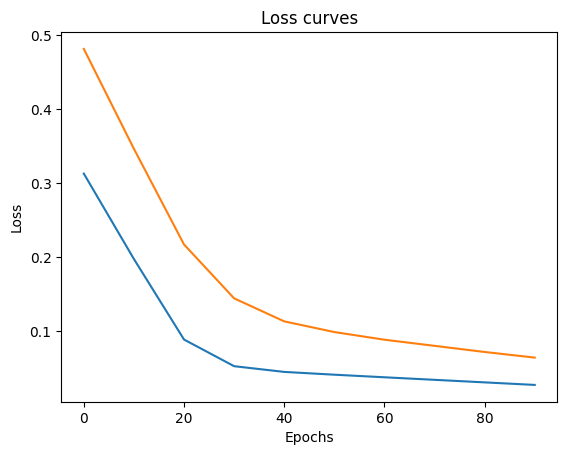

In [26]:
import numpy as np 


# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label='Train loss')
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).numpy()), label='Test loss')
plt.title('Loss curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

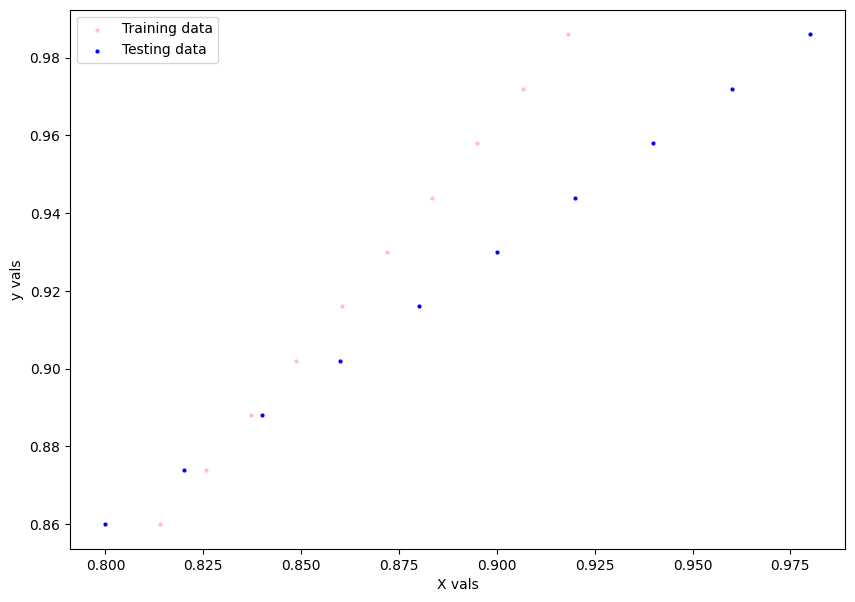

In [20]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

plot_predictions(y_preds_new, y_test)

In [28]:
# Saving a model in PyTorch

# 1. torch.save()
# 2. torch.load()
# 3. torch.nn.Module.load_state_dict()

# Saving our PyTorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = 'PyTorch.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f'Saving model to: {MODEL_SAVE_PATH}')
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models\PyTorch.pth


In [29]:
# Loading a PyTorch model
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

Putting it all together

In [53]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [54]:
# Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


In [55]:
# Create some data using the linear regression formula of y = weight * X + bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

In [56]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [57]:
# Plot the data

def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):
    # Plots training data, test data and compares predictions 

    plt.figure(figsize=(10,7))

    # Plot training data in pink
    plt.scatter(train_data, train_labels, color='Pink', s=4, label='Training data')

    # Plot test data in green
    plt.scatter(test_data, test_labels, color='Blue', s=4, label='Testing data')

    # Are there predictions?
    if predictions is not None:
        plt.scatter(test_data, predictions, color='Red', s=4, label='Training data')

    plt.xlabel('X vals')
    plt.ylabel('y vals')
    plt.legend()
    plt.show()

# plot_predictions()

In [58]:
# Building a PyTorch Linear model
# Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1, # 1 input
                                      out_features=1) # 1 output

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    

# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()      

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [59]:
# Check the model current device
next(model_1.parameters()).device

# Set the model to use the target device 
model_1.to(device)
next(model_1.parameters()).device


device(type='cpu')

In [60]:
# Training 
# For training we need:
# 1. Loss function
# 2. Optimiser
# 3. Training loop
# 4. Testing loop

# Setup loss function
loss_fn = nn.L1Loss() # MAE

# Setup optimiser
optimiser = torch.optim.SGD(params=model_1.parameters() ,lr=0.01)

In [61]:
# Lets write a training loop
torch.manual_seed(42)

epochs = 200

for epoch in range(epochs):
    model_1.train()

    # Forward pass
    y_pred = model_1(X_train)

    # Calculate the loss
    loss = loss_fn(y_pred, y_train)

    # Optimiser zero grad
    optimiser.zero_grad()

    # Backprogagation
    loss.backward()

    # Optimiser step
    optimiser.step()

    # Testing
    model_1.eval()
    with torch.inference_mode():
        text_pred = model_1(X_test)

        test_loss = loss_fn(test_pred, y_test)

    # Print out what is happening 
    if epoch % 10 == 0:
        print(f"Epich: {epoch}, Loss: {loss}, Test loss: {test_loss}")

Epich: 0, Loss: 0.5551779866218567, Test loss: 0.05687814950942993
Epich: 10, Loss: 0.4399680495262146, Test loss: 0.05687814950942993
Epich: 20, Loss: 0.3247582018375397, Test loss: 0.05687814950942993
Epich: 30, Loss: 0.20954827964305878, Test loss: 0.05687814950942993
Epich: 40, Loss: 0.09433844685554504, Test loss: 0.05687814950942993
Epich: 50, Loss: 0.023886386305093765, Test loss: 0.05687814950942993
Epich: 60, Loss: 0.0199567973613739, Test loss: 0.05687814950942993
Epich: 70, Loss: 0.016517987474799156, Test loss: 0.05687814950942993
Epich: 80, Loss: 0.013089170679450035, Test loss: 0.05687814950942993
Epich: 90, Loss: 0.009653178043663502, Test loss: 0.05687814950942993
Epich: 100, Loss: 0.006215679459273815, Test loss: 0.05687814950942993
Epich: 110, Loss: 0.002787243574857712, Test loss: 0.05687814950942993
Epich: 120, Loss: 0.0012645035749301314, Test loss: 0.05687814950942993
Epich: 130, Loss: 0.0012645035749301314, Test loss: 0.05687814950942993
Epich: 140, Loss: 0.00126

In [62]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [ ]:
# Making and evaluating predictions
# Turn model into evaluation mode

model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)




tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

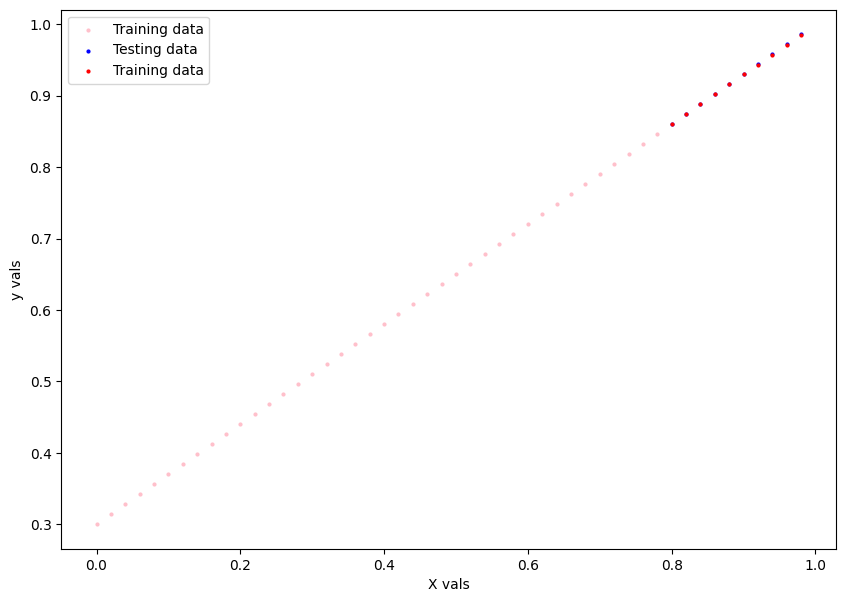

In [66]:
# Check out our plot predictions visually
plot_predictions(predictions=y_preds)

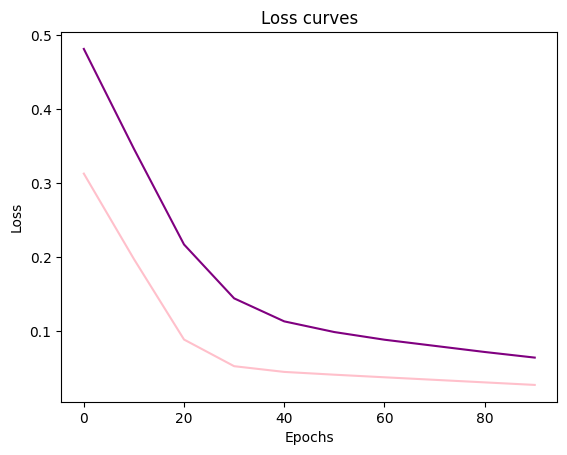

In [68]:
import numpy as np 

# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label='Train loss', color='Pink')
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).numpy()), label='Test loss', color='Purple')
plt.title('Loss curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [72]:
# Saving and loading a trained model
from pathlib import Path

# Create models directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save path
MODEL_NAME = 'PyTorch.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Save model to : {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Save model to : models\PyTorch.pth


In [ ]:
# Load a PyTorch model
loaded_model_1 = LinearRegressionModelV2()

# Load the saved model 1 state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Loaded model to device
loaded_model_1.to(device)

# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)

# Should all be true 
loaded_model_1_preds == y_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])